In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

# Tìm file dữ liệu để notebook chạy được trong VS Code/Jupyter hoặc Colab.
DATA_FILENAME = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

data_candidates = [
    Path("../data/raw") / DATA_FILENAME,
    Path("../data") / DATA_FILENAME,
    Path("data/raw") / DATA_FILENAME,
    Path("data") / DATA_FILENAME,
    Path(DATA_FILENAME),
    Path("../WA_Fn-UseC_-Telco-Customer-Churn(1).csv"),
    Path("WA_Fn-UseC_-Telco-Customer-Churn(1).csv"),
]

DATA_PATH = next((p for p in data_candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy file CSV. Hãy đặt file vào data/raw/ hoặc data/ "
        "hoặc cùng thư mục với notebook."
    )

# Tìm thư mục lưu hình.
figure_candidates = [
    Path("../reports/figures"),
    Path("reports/figures"),
]

FIGURES_DIR = next((p for p in figure_candidates if p.exists()), figure_candidates[0])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("Figures path:", FIGURES_DIR)


Data path: ..\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
Figures path: ..\reports\figures


In [2]:
# Đọc dữ liệu
df = pd.read_csv(DATA_PATH)

print("Kích thước dữ liệu:", df.shape)
df.head()


Kích thước dữ liệu: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Kiểm tra cấu trúc và kiểu dữ liệu


In [3]:
print("===== CẤU TRÚC DỮ LIỆU =====")
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

print("\nTên các cột:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

print("\nThông tin kiểu dữ liệu:")
df.info()


===== CẤU TRÚC DỮ LIỆU =====
Số dòng: 7043
Số cột: 21

Tên các cột:
1. customerID
2. gender
3. SeniorCitizen
4. Partner
5. Dependents
6. tenure
7. PhoneService
8. MultipleLines
9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn

Thông tin kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   I

In [4]:
# Thống kê dòng trùng và customerID trùng
print("Số dòng trùng:", df.duplicated().sum())
print("Số customerID duy nhất:", df["customerID"].nunique())
print("Tổng số dòng:", len(df))


Số dòng trùng: 0
Số customerID duy nhất: 7043
Tổng số dòng: 7043


## 2. Kiểm tra missing values


In [5]:
missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Column": missing.index,
    "Missing": missing.values
})

missing_summary = missing_summary[missing_summary["Missing"] > 0]

print("Missing values được pandas nhận diện:")
display(missing_summary if not missing_summary.empty else pd.DataFrame({"Thông báo": ["Không có NaN ban đầu"]}))

print("\nTổng missing values ban đầu:", df.isnull().sum().sum())


Missing values được pandas nhận diện:


,Thông báo
0,Không có NaN ban đầu



Tổng missing values ban đầu: 0


### Kiểm tra 11 giá trị trống dạng chuỗi trong `TotalCharges`

`TotalCharges` ban đầu có kiểu `object`. Ngoài các `NaN` mà `isnull()` có thể phát hiện, cột này còn chứa các giá trị trống được lưu dưới dạng chuỗi `" "`. Cần xác nhận chính xác số lượng các giá trị này trước khi chuyển sang kiểu số.


In [6]:
blank_totalcharges = df["TotalCharges"].astype(str).str.strip().eq("")

print(
    "Số giá trị trống dạng chuỗi trong TotalCharges:",
    blank_totalcharges.sum()
)

df.loc[
    blank_totalcharges,
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]


Số giá trị trống dạng chuỗi trong TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


## 3. Chuyển `TotalCharges` sang số và xử lý giá trị thiếu


In [7]:
# Chuyển TotalCharges từ object sang số.
# Các chuỗi trống " " sẽ trở thành NaN.
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Kiểu dữ liệu TotalCharges:", df["TotalCharges"].dtype)
print("Số giá trị thiếu sau khi chuyển sang số:", df["TotalCharges"].isna().sum())


Kiểu dữ liệu TotalCharges: float64
Số giá trị thiếu sau khi chuyển sang số: 11


In [8]:
# Impute 11 giá trị thiếu trong TotalCharges bằng median.
# Không xóa dòng để giữ nguyên 7.043 khách hàng.
median_totalcharges = df["TotalCharges"].median()
missing_before_impute = df["TotalCharges"].isna().sum()

df["TotalCharges"] = df["TotalCharges"].fillna(median_totalcharges)

print("Số dòng trước khi xử lý:", len(df))
print("Số giá trị thiếu trước khi impute:", missing_before_impute)
print("Median TotalCharges dùng để impute:", median_totalcharges)
print("Số giá trị đã impute:", missing_before_impute)
print("Kích thước dữ liệu sau khi xử lý:", df.shape)
print("Missing TotalCharges còn lại:", df["TotalCharges"].isna().sum())

Số dòng trước khi xử lý: 7043
Số giá trị thiếu trước khi impute: 11
Median TotalCharges dùng để impute: 1397.475
Số giá trị đã impute: 11
Kích thước dữ liệu sau khi xử lý: (7043, 21)
Missing TotalCharges còn lại: 0


In [9]:
print("===== KIỂM TRA SAU KHI LÀM SẠCH =====")
print("Kích thước:", df.shape)
print("Tổng missing values:", df.isnull().sum().sum())
print("Kiểu TotalCharges:", df["TotalCharges"].dtype)
print("Median TotalCharges:", df["TotalCharges"].median())

===== KIỂM TRA SAU KHI LÀM SẠCH =====
Kích thước: (7043, 21)
Tổng missing values: 0
Kiểu TotalCharges: float64
Median TotalCharges: 1397.475


## 4. Mã hóa tạm `Churn` để tính tương quan

Giữ nguyên cột `Churn` dạng `Yes/No` để phục vụ các biểu đồ phân loại. Tạo thêm `Churn_num` với `No = 0` và `Yes = 1` để dùng trong correlation heatmap.


In [10]:
df["Churn_num"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Kiểm tra mã hóa:")
display(df[["Churn", "Churn_num"]].head())

print("\nGiá trị Churn_num:")
print(df["Churn_num"].value_counts(dropna=False))


Kiểm tra mã hóa:


,Churn,Churn_num
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1



Giá trị Churn_num:
Churn_num
0    5174
1    1869
Name: count, dtype: int64


## 5. Phân bố Churn


In [11]:
churn_summary = pd.DataFrame({
    "Count": df["Churn"].value_counts(),
    "Percentage": df["Churn"].value_counts(normalize=True).mul(100)
})

display(churn_summary)


,Count,Percentage
Churn,,
No,5174,73.463013
Yes,1869,26.536987


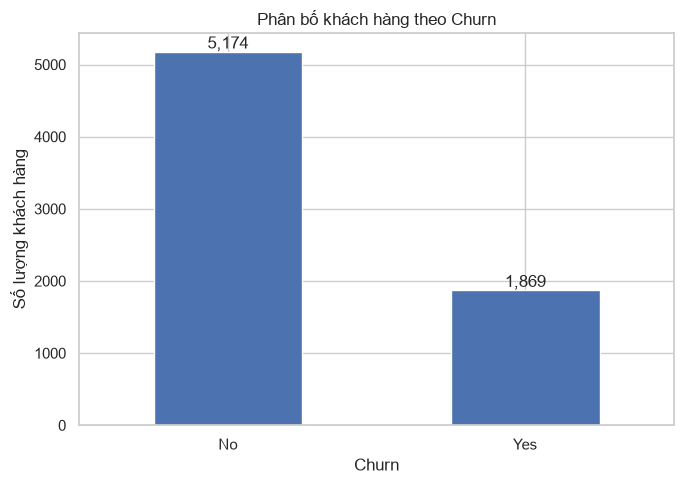

In [12]:
plt.figure(figsize=(7, 5))

churn_counts = df["Churn"].value_counts()
ax = churn_counts.plot(kind="bar")

plt.title("Phân bố khách hàng theo Churn")
plt.xlabel("Churn")
plt.ylabel("Số lượng khách hàng")
plt.xticks(rotation=0)

for i, value in enumerate(churn_counts):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "01_churn_distribution.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()


### Insight

Trong **7.043 khách hàng**, có **5.174 khách hàng không Churn (73,46%)** và **1.869 khách hàng Churn (26,54%)**. Nhóm Churn chiếm hơn một phần tư tổng số khách hàng, cho thấy bài toán mất khách hàng là đáng quan tâm và cần tiếp tục phân tích các yếu tố liên quan.

## 6. Churn theo Contract


In [13]:
contract_churn = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
)

display(contract_churn)


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


<Figure size 900x500 with 0 Axes>

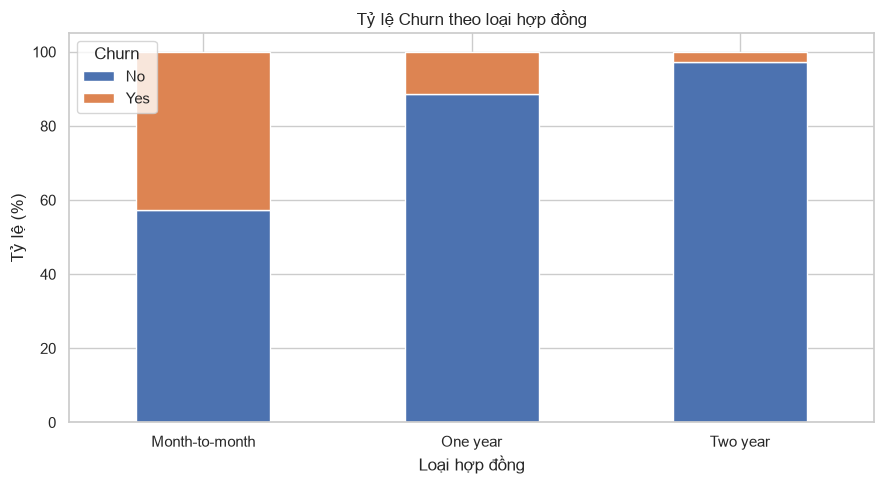

In [14]:
plt.figure(figsize=(9, 5))

ax = contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Tỷ lệ Churn theo loại hợp đồng")
plt.xlabel("Loại hợp đồng")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "02_churn_by_contract.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()


### Insight

Trong **7.043 khách hàng**, nhóm **Month-to-month** có tỷ lệ Churn cao nhất, khoảng **42,71%**. Trong khi đó, tỷ lệ Churn của **One year** là **11,27%** và **Two year** chỉ khoảng **2,83%**. Điều này cho thấy khách hàng có hợp đồng ngắn hạn có xu hướng rời bỏ dịch vụ cao hơn đáng kể so với khách hàng ký hợp đồng dài hạn.

## 7. Churn theo PaymentMethod


In [15]:
payment_churn = (
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
)

display(payment_churn)


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


<Figure size 1000x500 with 0 Axes>

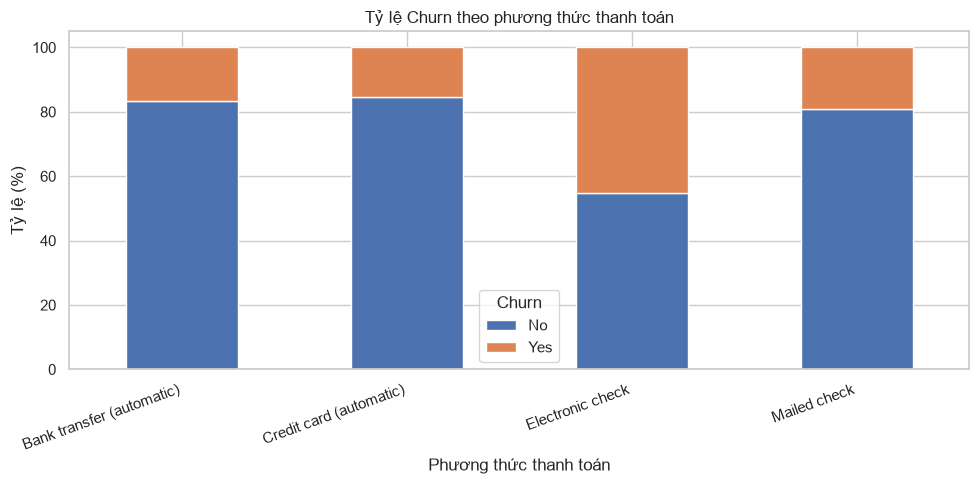

In [16]:
plt.figure(figsize=(10, 5))

ax = payment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Tỷ lệ Churn theo phương thức thanh toán")
plt.xlabel("Phương thức thanh toán")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Churn")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "03_churn_by_payment_method.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()


### Insight

Trong **7.043 khách hàng**, nhóm sử dụng **Electronic check** có tỷ lệ Churn cao nhất, khoảng **45,29%**. Các nhóm còn lại có tỷ lệ Churn thấp hơn: **Mailed check 19,11%**, **Bank transfer (automatic) 16,71%** và **Credit card (automatic) 15,24%**. Electronic check vì vậy là nhóm đáng được chú ý khi phân tích nguyên nhân Churn.

## 8. Tenure theo Churn


<Figure size 800x500 with 0 Axes>

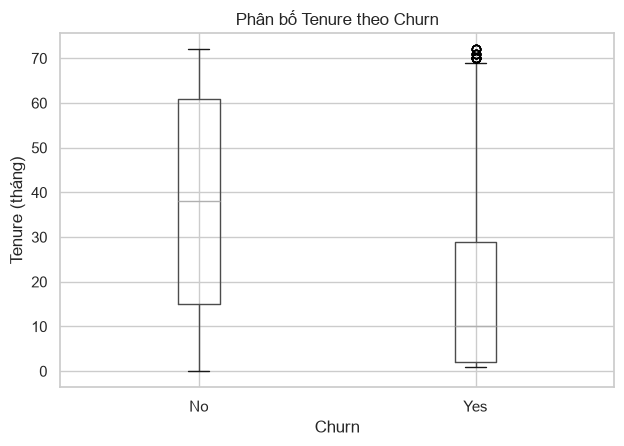

In [17]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="tenure",
    by="Churn"
)

plt.suptitle("")
plt.title("Phân bố Tenure theo Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (tháng)")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "04_tenure_distribution_by_churn.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()


### Insight

Trong **7.043 khách hàng**, median **tenure** của nhóm Churn là **10 tháng**, thấp hơn nhiều so với **38 tháng** của nhóm không Churn. Điều này cho thấy khách hàng mới sử dụng dịch vụ có xu hướng Churn cao hơn, vì vậy giai đoạn đầu của vòng đời khách hàng có thể là thời điểm cần tăng cường chăm sóc và giữ chân.

## 9. MonthlyCharges theo Churn


<Figure size 800x500 with 0 Axes>

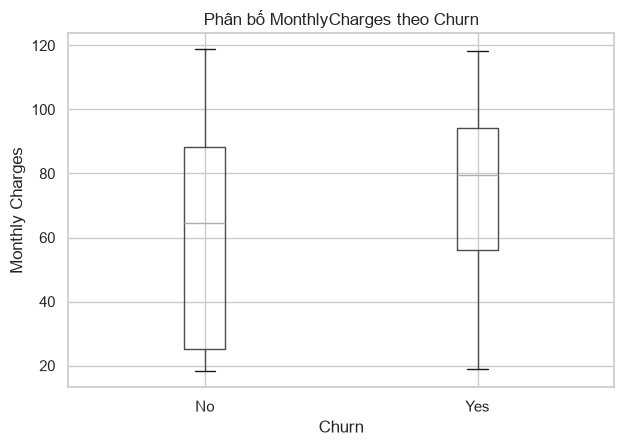

In [18]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.suptitle("")
plt.title("Phân bố MonthlyCharges theo Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "05_monthly_charges_by_churn.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()


### Insight

Trong **7.043 khách hàng**, median **MonthlyCharges** của nhóm Churn là khoảng **79,65**, cao hơn nhóm không Churn khoảng **64,43**. Điều này cho thấy khách hàng có mức phí hàng tháng cao có xu hướng Churn nhiều hơn trong bộ dữ liệu, nhưng đây chỉ là mối liên hệ quan sát được và chưa thể kết luận về quan hệ nhân quả.

## 10. Correlation Heatmap


In [19]:
heatmap_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_num"
]

corr = df[heatmap_cols].corr()

display(corr)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_num
SeniorCitizen,1.000000,0.016567,0.220173,0.102652,0.150889
tenure,0.016567,1.000000,0.247900,0.825464,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.650864,0.193356
TotalCharges,0.102652,0.825464,0.650864,1.000000,-0.199037
Churn_num,0.150889,-0.352229,0.193356,-0.199037,1.000000


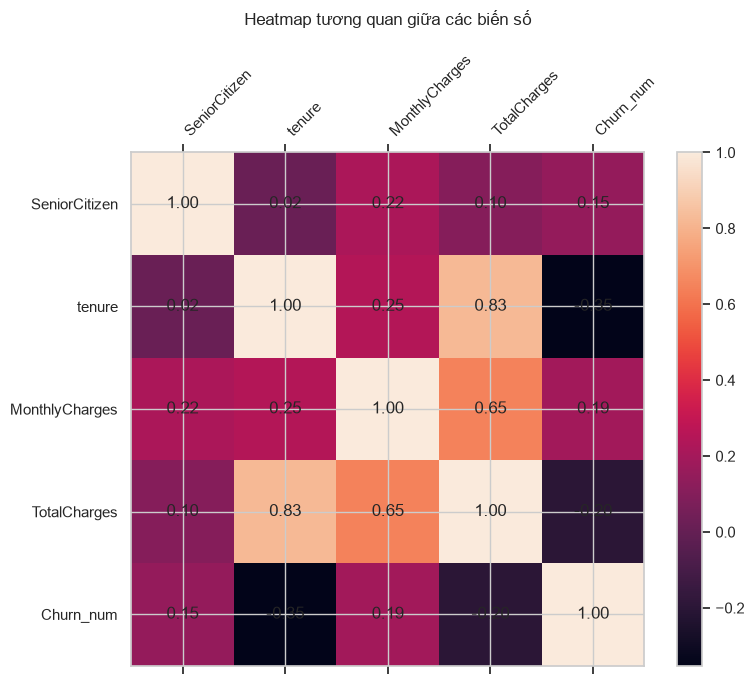

In [21]:
fig, ax = plt.subplots(figsize=(9, 7))

image = ax.matshow(corr)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="left")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Heatmap tương quan giữa các biến số", pad=20)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "06_correlation_heatmap.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()


### Insight

Trên **7.043 khách hàng**, `tenure` có tương quan âm mạnh nhất với `Churn_num` trong nhóm biến số được xét (**r ≈ -0,35**), cho thấy khách hàng có thời gian sử dụng lâu hơn có xu hướng Churn thấp hơn. `MonthlyCharges` có tương quan dương (**r ≈ 0,19**), còn `TotalCharges` có tương quan âm (**r ≈ -0,20**). Các hệ số này chỉ phản ánh mức độ liên hệ tuyến tính, không chứng minh quan hệ nhân quả.

## 11. Kiểm tra 6 biểu đồ đã được lưu

Các biểu đồ phải vừa được hiển thị trong notebook vừa được lưu trong `reports/figures/`.


In [22]:
expected_figures = [
    "01_churn_distribution.png",
    "02_churn_by_contract.png",
    "03_churn_by_payment_method.png",
    "04_tenure_distribution_by_churn.png",
    "05_monthly_charges_by_churn.png",
    "06_correlation_heatmap.png",
]

print("===== KIỂM TRA FIGURES =====")

for name in expected_figures:
    path = FIGURES_DIR / name
    print(f"{name}: {'OK' if path.exists() else 'THIẾU'}")


===== KIỂM TRA FIGURES =====
01_churn_distribution.png: OK
02_churn_by_contract.png: OK
03_churn_by_payment_method.png: OK
04_tenure_distribution_by_churn.png: OK
05_monthly_charges_by_churn.png: OK
06_correlation_heatmap.png: OK


✅ Đã tạo thành công Ảnh 8: 08_classification_comparison.png


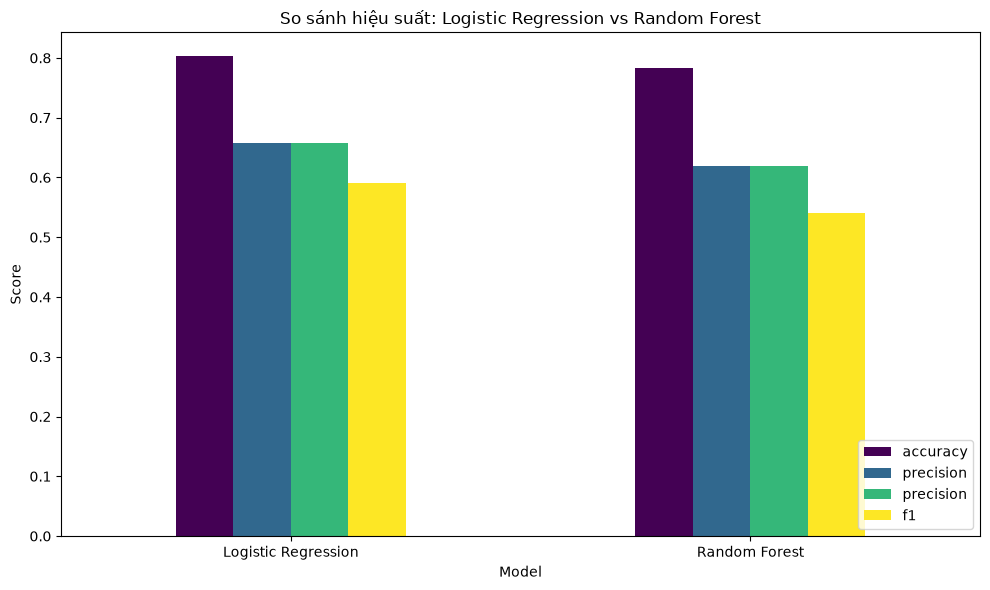

✅ Đã tạo thành công Ảnh 12: 12_cluster_profile.png


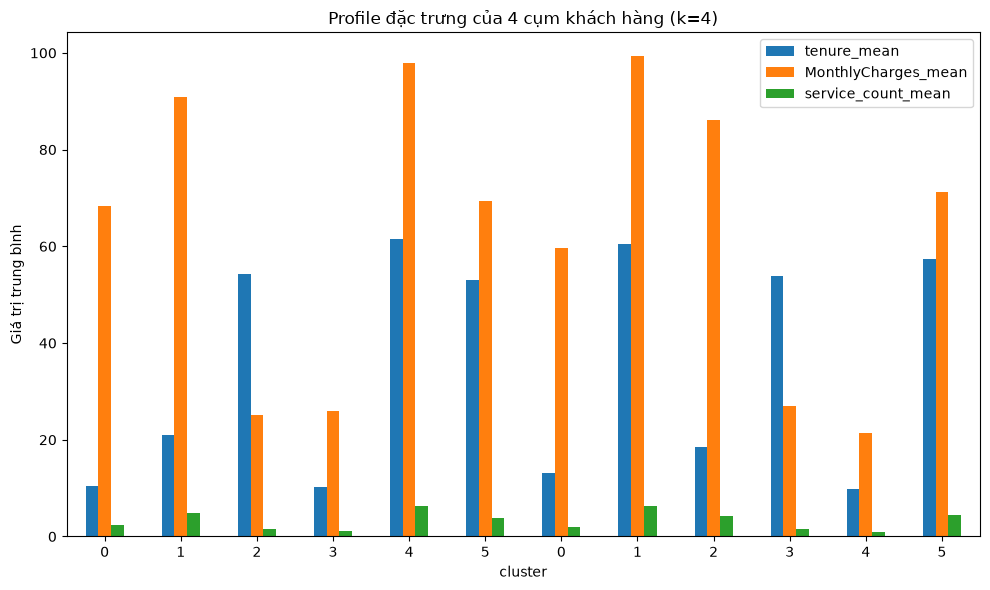

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Đảm bảo thư mục lưu ảnh tồn tại
os.makedirs('../reports/figures', exist_ok=True)

# ==========================================
# TẠO ẢNH 8: TỰ ĐỘNG TÌM CỘT VÀ VẼ
# ==========================================
try:
    df_class = pd.read_csv('../reports/classification_results.csv')
    
    # Tự động dò tìm tên cột dựa trên từ khóa (bất chấp viết hoa/thường hay viết tắt)
    col_model = next((c for c in df_class.columns if 'model' in c.lower() or 'name' in c.lower()), df_class.columns[0])
    col_acc = next((c for c in df_class.columns if 'acc' in c.lower()), None)
    col_prec = next((c for c in df_class.columns if 'prec' in c.lower()), None)
    col_rec = next((c for c in df_class.columns if 'rec' in c.lower()), None)
    col_f1 = next((c for c in df_class.columns if 'f1' in c.lower()), None)
    
    # Lọc ra những cột tìm thấy
    cols_class_plot = [c for c in [col_acc, col_prec, col_rec, col_f1] if c is not None]
    
    if cols_class_plot:
        ax = df_class.set_index(col_model)[cols_class_plot].plot(kind='bar', figsize=(10, 6), colormap='viridis')
        plt.title('So sánh hiệu suất: Logistic Regression vs Random Forest')
        plt.ylabel('Score')
        plt.xticks(rotation=0)
        plt.legend(loc='lower right')
        plt.tight_layout()
        
        plt.savefig('../reports/figures/08_classification_comparison.png', dpi=300)
        print("✅ Đã tạo thành công Ảnh 8: 08_classification_comparison.png")
        plt.show()
    else:
        print(f"⚠️ Ảnh 8: Không dò ra cột điểm. Các cột file bạn đang có là: {list(df_class.columns)}")
except Exception as e:
    print(f"❌ Lỗi file classification_results.csv: {e}")


# ==========================================
# TẠO ẢNH 12: TỰ ĐỘNG TÌM CỘT VÀ VẼ
# ==========================================
try:
    df_cluster = pd.read_csv('../reports/cluster_summary_k4.csv')
    
    # Tự động dò tìm tên cột đặc trưng
    col_cluster = next((c for c in df_cluster.columns if 'cluster' in c.lower() or 'cụm' in c.lower()), None)
    col_tenure = next((c for c in df_cluster.columns if 'tenure' in c.lower()), None)
    col_monthly = next((c for c in df_cluster.columns if 'month' in c.lower()), None)
    col_service = next((c for c in df_cluster.columns if 'service' in c.lower()), None)
    
    cols_cluster_plot = [c for c in [col_tenure, col_monthly, col_service] if c is not None]
    
    if cols_cluster_plot:
        if col_cluster:
            df_cluster.set_index(col_cluster)[cols_cluster_plot].plot(kind='bar', figsize=(10, 6))
        else:
            df_cluster[cols_cluster_plot].plot(kind='bar', figsize=(10, 6))
            
        plt.title('Profile đặc trưng của 4 cụm khách hàng (k=4)')
        plt.ylabel('Giá trị trung bình')
        plt.xticks(rotation=0)
        plt.tight_layout()
        
        plt.savefig('../reports/figures/12_cluster_profile.png', dpi=300)
        print("✅ Đã tạo thành công Ảnh 12: 12_cluster_profile.png")
        plt.show()
    else:
        print(f"⚠️ Ảnh 12: Không dò ra cột đặc trưng. Các cột file bạn đang có là: {list(df_cluster.columns)}")
except Exception as e:
    print(f"❌ Lỗi file cluster_summary_k4.csv: {e}")